In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("Project1.ipynb")

In [ ]:
rng_seed = 42

# Project 1

# <em> Optimization, Monte Carlo Problems, pocoMC </em>
<br>

Welcome to your first project. Unlike the homework, you will generally receive less guidance on projects but are still expected to do the work required. This project primarily covers sampling and the use of MCMC methods. You will be analyzing some data using a number of methods for parameter inference.

Though there will be physics involved in these projects, the physical quantities and equations are generally given to you, while you are expected to use the physics equations to produce data analysis results. Accordingly, autograder will be less through for these questions, and most of the project will be graded manually, so make sure you include documentation with your code!


### Imports

In [1]:
import numpy as np
from scipy.integrate import quad
#For plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

***

# Problem 1: Constraints on Galaxy Clustering

Parameter constraints methods are used in many physical problems. In this project, we consider the use of two different methods, Maximum Likelihood Estimation (MLE) and Markov Chain Monte Carlo (MCMC), to constrain Halo Occupation Distribution (HOD) models.

Here, we consider constraints on the Halo Occupation Distribution (HOD) models for projected galaxy clustering.

HOD models are used to interpret the relation of galaxy distributions in large scale structure to the dark matter distribution. They describe related properties of the galaxy distribution within a dark matter halo: The probability distribution of the number of galaxies within that halo in relation to the mass of the halo, the distribution in space of galaxies withing the DM halo and the distribution in velocity of galaxies in the halo.

Traditional HOD models make two assumptions: (1) that all galaxies reside in dark matter haloes and are biased tracers of the underlying matter density and (2) galaxies occupy halos **only** as a function of the halo mass $M_{vir}$. However, these are not necessarily correct, an effect called *halo assembly bias* could be significant. They also add additional parameters to the HOD model. In this problem, we will infer some HOD model parameters given some input data using MCMC.

First, we will describe the parameters. HOD models usually treat central galaxies and satellite galaxies in a halo separately, and the occupation statistics of the central galaxy will be different than the occupation statistics of the satellite galaxies in the halo.
The average number of central galaxies in a halo of mass $M$ is given by

$$\langle N_{cen}\rangle_{M} = \frac12 \left[1 + \mathrm{erf}\left( \frac{\log M - \log M_{\mathrm{min}}}{\sigma_{\log M}}\right)\right]$$

While the average number of satellite galaxies in a halo of mass $M$ is given by

$$\langle N_{sat}\rangle_{M} = \left[\frac{M-M_0}{M_1}\right]^\alpha$$

The parameter $M_{\mathrm{min}}$ describes the halo mass at which the halo has 50\% probability to host a central galaxy, while the parameter $\sigma_{\log M}$ can be considered the rate at which the likelihood of the central galaxy to exist increases alongside halo mass. The parameter $M_1$ is the halo mass at which an average halo would host one satellite galaxy, while $M_0$ is the halo mass at which an average halo would not have a satellite galaxy. $\alpha$ is the power-law exponent relation parameter between the number of satellites and the halo mass. Lastly, we also have the two parameters $A_{cen}$ and $A_{sat}$, quantify describe the halo assembly bias.

In summary, we take a likelihood model of the Halo Occupation Distribution and infer the following parameters:
$$[\log(M_{\mathrm{min}}), \sigma_{\log M}, \log(M_0), \log(M_1), \alpha, A_{cen}, A_{sat}]$$

(This problem is based on the following paper: https://arxiv.org/pdf/1606.07817.pdf)

In [7]:
import numpy as np
import corner
from scipy.stats import uniform
from tabcorr import TabCorr
from halotools.empirical_models import HodModelFactory
from halotools.empirical_models import AssembiasZheng07Cens
from halotools.empirical_models import AssembiasZheng07Sats

import numdifftools

In [8]:
# Load data
halotab = TabCorr.read('./zentner19data/bolplanck.hdf5')
cens_occ_model = AssembiasZheng07Cens()
sats_occ_model = AssembiasZheng07Sats()
model = HodModelFactory(centrals_occupation=cens_occ_model,
                        satellites_occupation=sats_occ_model)

n_obs = 6.37e-3
n_err = 0.75e-3
wp_obs = np.genfromtxt('./zentner19data/wp_dr72_bright0_mr20.0_z0.106_nj400')[:, 1] # Observed galaxy two-point function
wp_cov = np.genfromtxt('./zentner19data/wpcov_dr72_bright0_mr20.0_z0.106_nj400') # Observed galaxy two-point function covariance.

First, we would like to define priors on the model parameters. Since we don't know too much beyond the range of the priors, we will define uniform priors for each parameter as given:

\begin{array}{ c|c }
 \text{Parameter} & \text{Prior Interval} \\
 \hline
 \log(M_{\mathrm{min}}) & [9.0, 14.0] \\
 \sigma_{\log M} & [0.01, 1.5]\\
 \log(M_0) & [9.0, 14.0]\\
 \log(M_1) & [10.7, 15.0]\\
 \alpha & [0.0, 2.0]\\
 A_{cen} & [-1.0, 1.0] \\
 A_{sat} & [-1.0, 1.0]
\end{array}

Furthermore, to constrain parameters, we need a description of the likelihood function of parameters. Here, following the accompanying paper to this problem, we define the likelihood of the form $\mathit{L} \propto e^{-\chi^2/2}$, with the $\chi^2$ given as

$$\chi^2 = \Delta w_{p,i}\, [C^{-1}]_{ij}\, \Delta w_{p, j} + \frac{(n_g^{\text{mock}} - n_g^{\text{obs}})^2}{\sigma^2_n}$$

with $ \Delta w_{p,i} \equiv w_p^{\text{mock}}(r_{p, i}) -  w_p^{\text{obs}}(r_{p, i})$ being the difference between the projected and observed two point correlation functions $w_{p}(r_{p,i})$. The observed $w_p^{\text{obs}}$ is given to you while the predicted $w_p^{\text{mock}}$ is received from the model (see below). The $r_{p,i}$ represents the 12 $r$ bins, and you can see that the given $w_p$ are indeed 12 dimensional. $C$ is the covariance matrix of the measurements (also given), and the term $\frac{(n_g^{\text{mock}} - n_g^{\text{obs}})^2}{\sigma^2_n}$ is the contribution from the difference between the predicted and measured galaxy number densities. ($n_g^{\text{mock}}$ is given by the model, while $\sigma_n$ and $n_g^{\text{obs}}$ are given from the data).

## **Problem Goals**

Using the likelihood function and priors given,  you are expected to compute constraints on the halo parameters in two different methods: first, using a **Maximum Likelihood Estimate (MLE)** approach where you assume the data is Gaussian, then using the **Metropolis-Hastings algorithm** for **Markov Chain Monte Carlo (MCMC)**. You are then expected to compare the results from these two methods and briefly discuss the differences. Lastly, compare the results to Figure 6 from https://arxiv.org/pdf/1606.07817.pdf.

<!-- BEGIN QUESTION -->

### Part 1. Define the Log Likelihood function


Given a set of data $X$ and a model $M(\theta)$ on this data with parameters $\theta$, we can define the likelihood function as the probability that the model with parameters $\theta$ describes the data:
$$L(\theta; X) = P(X | \theta)$$

Usually, we work in the log space as the log-likelihood is easier to define and optimize. As the log function is monotonic, anything that yields the maximum or minimum log-likelihood would then also yield the maximum or minimum likelihood. The log-likelihood is defined as
$$\ell(\theta;X) = \log(L(\theta; X))$$


<span style="color:blue"> <i> Using this chi square given above, define the priors and the log likelihood function.



In [33]:
# Define log-likelihood function
names = ['logMmin', 'sigma_logM', 'logM0', 'logM1', 'alpha',
         'mean_occupation_centrals_assembias_param1',
         'mean_occupation_satellites_assembias_param1']

bounds = [
    (9.0, 14.0),      # logMmin
    (0.01, 1.5),      # sigma_logM
    (9.0, 14.0),      # logM0
    (10.7, 15.0),     # logM1
    (0.0, 2.0),       # alpha
    (-1.0, 1.0),      # A_cen
    (-1.0, 1.0)       # A_sat
]

def log_likelihood(theta):
    theta = theta.copy()  # copy the x so as to not change the original
    model.param_dict.update(dict(zip(names, theta)))  # update model with input parameters
    n_mod, wp_mod = halotab.predict(model)  # get predicted results
    
    # Calculate chi-square
    delta_wp = wp_mod - wp_obs
    cov_inv = np.linalg.inv(wp_cov)
    chi2_wp = delta_wp @ cov_inv @ delta_wp
    chi2_n = ((n_mod - n_obs) / n_err) ** 2
    chi2 = chi2_wp + chi2_n
    
    # Log likelihood is -chi^2/2
    return -chi2 / 2

In [ ]:
grader.check("q1.1")

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Part 2. Maximum Likelihood Estimate / Maximum A Posteriori

Given a log likelihood function $\ell(\theta; X)$, in the frequentist set-up we can calculate the maximum likelihood estimate (MLE) of our parameters $\theta$ by finding the MLE best fit parameters $\widehat{\theta}$

$$\widehat{\theta} = \mathrm{argmax}_\theta \; \ell(\theta; X)$$

However, in this problem, we don't just want to find the *best fit parameters* $\widehat{\theta}$, but we also want to find the *uncertainties* of these best fit parameters, as well as the covariances of these parameters and their distribution in parameter space.

The Fisher Information Matrix could help us find the parameter covariance. Recall that the Fisher Matrix is defined as
$$F_{ij} = - \left\langle \frac{∂^2}{∂\theta_i∂\theta_j} \ell(\theta; X)\right\rangle_{\theta_{MLE}}$$
(Note that as described in the lecture notes, the fisher matrix is evaluated at the best-fit MLE parameters) The Fisher matrix also has the property such that its inverse yields the covariance matrix.
$$C^{-1} = F$$

To compute the Fisher information, we make use of the Hessian matrix of the log-likelihood. This is defined as
$$H_{ij} = \frac{∂^2}{∂\theta_i∂\theta_j} \ell(\theta; X)$$ which means that the Fisher Information matrix is the negative expectation of the Hessian
$$F = -\left\langle H \right\rangle$$

Note: this is only true in the assumption of large, independent samples from the likelihood, when distribution on $\theta$ exhibits asymptotic normality.
$$\hat{\theta} \sim N\left(\theta, \frac{F(\theta)^{-1}}{n} \right)$$
By the Laplace approximation, this indicates that the Hessian would converge to the Fisher Information Matrix.

In practice, this symbolizes that the Hessian of the log likelihood can be used to approximate the Fisher matrix. Under the assumption that the parameter space is Gaussian distributed then, we can use the Hessian of the likelihood to calculate the covariance matrix and plot Gaussian stair plots showing the distribution in parameter space.

**The goal of this section is to accomplish this task. Find the parameters that maximize the log likelihood within the prior bounds given above, and plot the parameter distributions for the parameters given, using the prior bounds as bounds of each of the stair plots.** To help in the plotting part, a skeleton stair plot code is provided, but you will have to modify the code to fit the parameters. (Note that technically, we are conducting Maximum A Posteriori (MAP) estimation of parameters as we're incorporating the uniform priors given earlier)

Hints:

1.   `scipy.optimize` allows the use of optimization methods with bounds on optimization parameters. Read the documentation and use a method that is able to do bounded optimization on the likelihood.
2.   To compute the Hessian on the log-likelihood function, use numerical finite difference methods and not automatic differentiation methods. This is because the likelihood function you constructed in Part 1 utilises packages which are not automatically differentiable by autograd or pytorch. The package `numdifftools` contains the function `numdifftools.Hessian` which will help you in this area.

In [34]:
# Use these labels for the parameters. Make sure you use the parameters in this order for the autograder!
from scipy.optimize import minimize

labels = [r'$\log M_{min}$', r'$\sigma_{\log M}$', r'$\log M_0$', r'$\log M_1$', r'$\alpha$', r'$A_c$', r'$A_s$']

# Initial guess (middle of bounds)
x0 = np.array([11.5, 0.755, 11.5, 12.85, 1.0, 0.0, 0.0])

# Minimize negative log likelihood (= maximize log likelihood)
opt_p = minimize(lambda x: -log_likelihood(x), x0, bounds=bounds, method='L-BFGS-B')

print(opt_p)

for i in range(len(labels)):
    print(r"MLE value of %s = %.5f" % (labels[i], opt_p.x[i]))

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 7.202143367143813
        x: [ 1.216e+01  6.678e-01  1.218e+01  1.327e+01  1.061e+00
             1.000e+00 -6.113e-02]
      nit: 73
      jac: [ 1.058e-01 -4.808e-02  5.693e-03 -9.371e-02  1.354e-01
            -4.989e+00  3.921e-03]
     nfev: 960
     njev: 120
 hess_inv: <7x7 LbfgsInvHessProduct with dtype=float64>
MLE value of $\log M_{min}$ = 12.15664
MLE value of $\sigma_{\log M}$ = 0.66780
MLE value of $\log M_0$ = 12.18342
MLE value of $\log M_1$ = 13.26772
MLE value of $\alpha$ = 1.06068
MLE value of $A_c$ = 1.00000
MLE value of $A_s$ = -0.06113


In [35]:
# Compute Hessian and Covariance Matrix
hess_func = numdifftools.Hessian(log_likelihood)
hessian = hess_func(opt_p.x)

# Fisher information is negative Hessian (for log likelihood)
fisher = -hessian

# Covariance is inverse of Fisher
cov_matrix = np.linalg.inv(fisher)

print("\nParameter uncertainties (1-sigma):")
for i in range(len(labels)):
    print("%s: %.5f +/- %.5f" % (labels[i], opt_p.x[i], np.sqrt(cov_matrix[i, i])))


Parameter uncertainties (1-sigma):
$\log M_{min}$: 12.15664 +/- 0.17593
$\sigma_{\log M}$: 0.66780 +/- 0.26328
$\log M_0$: 12.18342 +/- 0.42561
$\log M_1$: 13.26772 +/- 0.09293
$\alpha$: 1.06068 +/- 0.07575
$A_c$: 1.00000 +/- 0.35814
$A_s$: -0.06113 +/- 0.27308


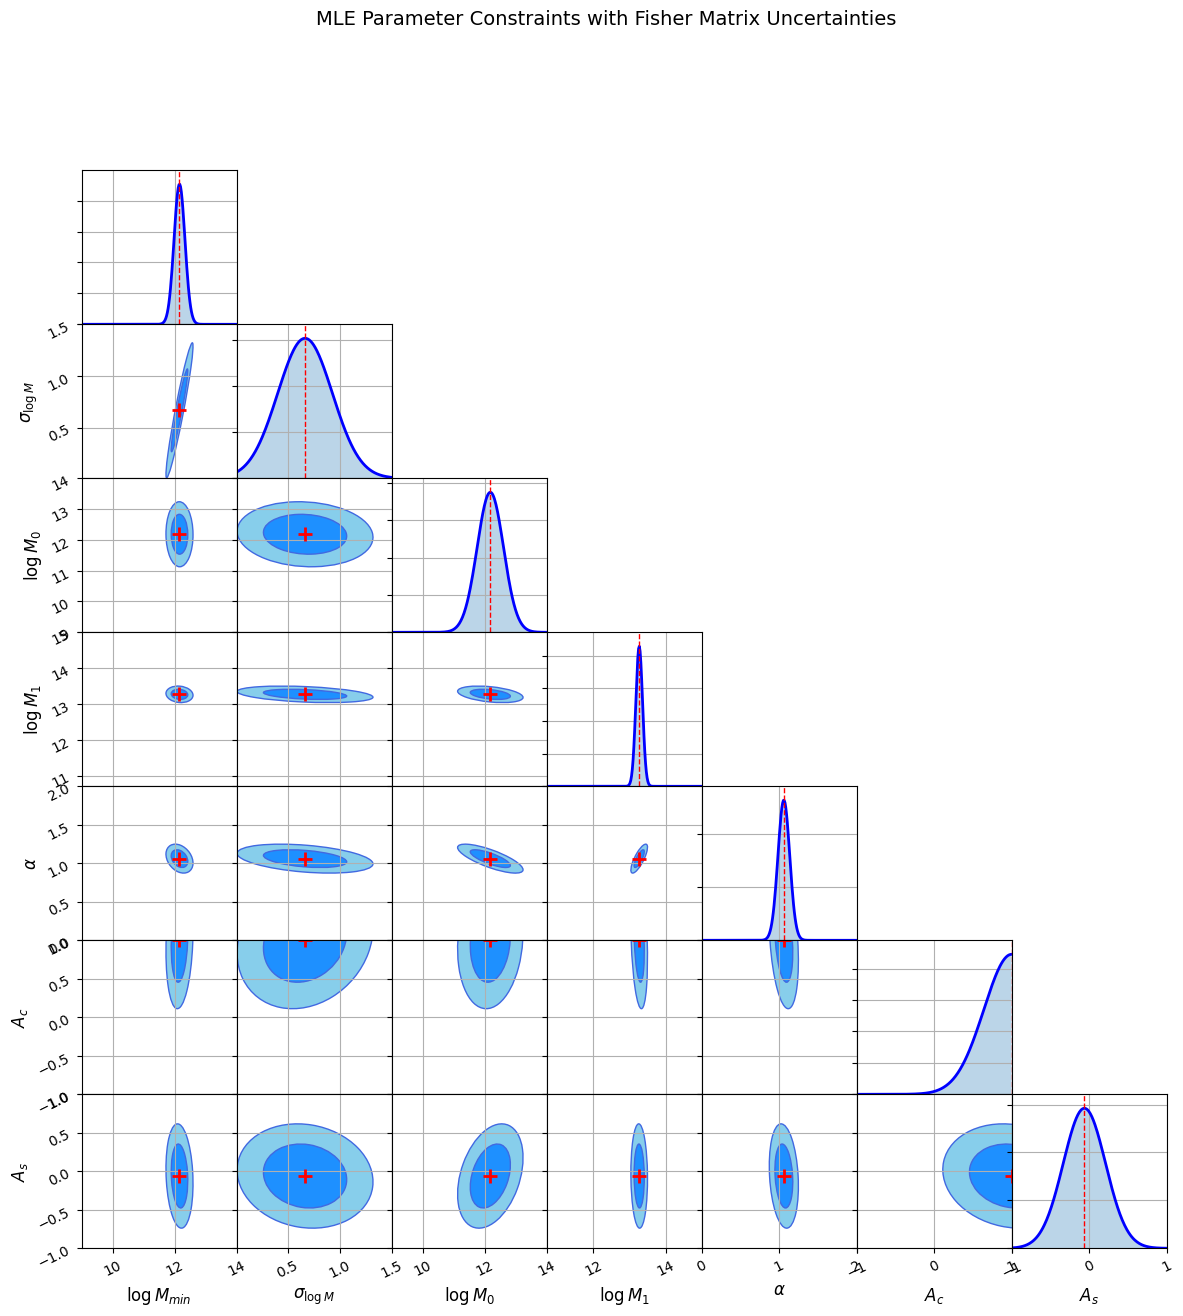

In [36]:
# Triangle Plot
from scipy.stats import norm

fig, axes = plt.subplots(7, 7, figsize=(14, 14))
fig.subplots_adjust(wspace=0, hspace=0)

for i in range(7):
    for j in range(7):
        ax = axes[i, j]
        if j > i:
            ax.axis('off')
            continue
        elif i == j:
            # diagonal part - 1D Gaussian distribution
            ax.grid(True)
            std = np.sqrt(cov_matrix[i, i])
            xarr = np.linspace(bounds[i][0], bounds[i][1], 200)
            yarr = norm.pdf(xarr, loc=opt_p.x[i], scale=std)
            ax.plot(xarr, yarr, 'b-', linewidth=2)
            ax.axvline(opt_p.x[i], color='r', linestyle='--', linewidth=1)
            ax.fill_between(xarr, yarr, alpha=0.3)
            ax.set_xlim(bounds[i][0], bounds[i][1])
            ax.set_ylim(0, yarr.max() * 1.1)
            ax.set_yticklabels([])
            if i != 6:
                ax.set_xticklabels([])
        else:
            # off-diagonal part - 2D confidence ellipses
            ax.grid(True)

            # Get 2x2 covariance submatrix for parameters j and i
            CovM = cov_matrix[np.ix_([j, i], [j, i])]

            # Get eigenvalue/vector using svd
            eigvec, eigval, u = np.linalg.svd(CovM)

            # Get semimajor/minor axes of the ellipse
            semimaj = np.sqrt(eigval[0]) * 2.0
            semimin = np.sqrt(eigval[1]) * 2.0

            # Rotation angle of the ellipse
            theta = np.arctan2(eigvec[0][1], eigvec[0][0])

            # Create ellipses (68% and 95% confidence intervals)
            ell = mpl.patches.Ellipse(
                xy=[opt_p.x[j], opt_p.x[i]], 
                width=1.52*semimaj, height=1.52*semimin, 
                angle=theta*180/np.pi, 
                facecolor='dodgerblue', edgecolor='royalblue', 
                label='68% confidence'
            )
            ell2 = mpl.patches.Ellipse(
                xy=[opt_p.x[j], opt_p.x[i]], 
                width=2.48*semimaj, height=2.48*semimin, 
                angle=theta*180/np.pi, 
                facecolor='skyblue', edgecolor='royalblue', 
                label='95% confidence'
            )

            ax.add_patch(ell2)
            ax.add_patch(ell)
            ax.plot(opt_p.x[j], opt_p.x[i], 'r+', markersize=10, markeredgewidth=2)

            ax.set_ylim(bounds[i][0], bounds[i][1])
            ax.set_xlim(bounds[j][0], bounds[j][1])

        if j != 0:
            ax.set_yticklabels([])
        if i != 6:
            ax.set_xticklabels([])
        if j == 0 and i != 0:
            ax.set_ylabel(labels[i], fontsize=12)
            [tl.set_rotation(26) for tl in ax.get_yticklabels()]
        if i == 6:
            ax.set_xlabel(labels[j], fontsize=12)
            [tl.set_rotation(26) for tl in ax.get_xticklabels()]

plt.suptitle('MLE Parameter Constraints with Fisher Matrix Uncertainties', fontsize=14, y=0.995)
plt.show()

In [ ]:
grader.check("q1.2")

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Part 3. Markov Chain Monte Carlo



In many cases, the likelihood or the posterior distribution over parameter space is highly non-Gaussian.
When the Gaussian approximation is no longer sufficient for parameter distribution estimation and sampling, we can instead use Markov Chain Monte Carlo methods to do sampling to get a better estimate for the distribution of parameters.



Here, we will use the `pocomc` package as an example case for parameter sampling estimation. Following the example, you are expected to conduct the same type of sampling with your own Metropolis-Hastings algorithm, and get the same resulting plot.

So we define the priors as a list to the `pc.Prior` function, each item in the list should be a uniform random variable given by `uniform(lower, upper-lower)`.


In [20]:
import pocomc as pc

In [21]:
# Define prior

prior = pc.Prior([
    uniform(9,14-9), # logMmin in [9,14]
    uniform(0.01,1.5-0.01), # sigma_logM in [0.01,1.5]
    uniform(9,14-9), # logM0 in [9,14]
    uniform(10.7,15.0-10.7), # logM1 in [10.7,15.0]
    uniform(0,2-0), # alpha in [0,2]
    uniform(-1,+1-(-1)), # mean_occupation_centrals_assembias_param1 in [-1,+1]
    uniform(-1,+1-(-1)), # mean_occupation_satellites_assembias_param1 in [-1,+1]
])

In [22]:
# Run pocoMC sampler (note that this should take ~ 5 minutes)

sampler = pc.Sampler(prior=prior, likelihood=log_likelihood)

sampler.run()

samples, weights, logl, logp = sampler.posterior()

logz, logz_err = sampler.evidence()

print('logZ = ', np.round(logz,4), '+-', np.round(logz_err,4))

Iter: 36it [02:19,  3.87s/it, beta=1, calls=45568, ESS=4015, logZ=-25.1, logP=-18.4, acc=0.596, steps=8, eff=1]       

logZ =  -24.8438 +- 0.0264


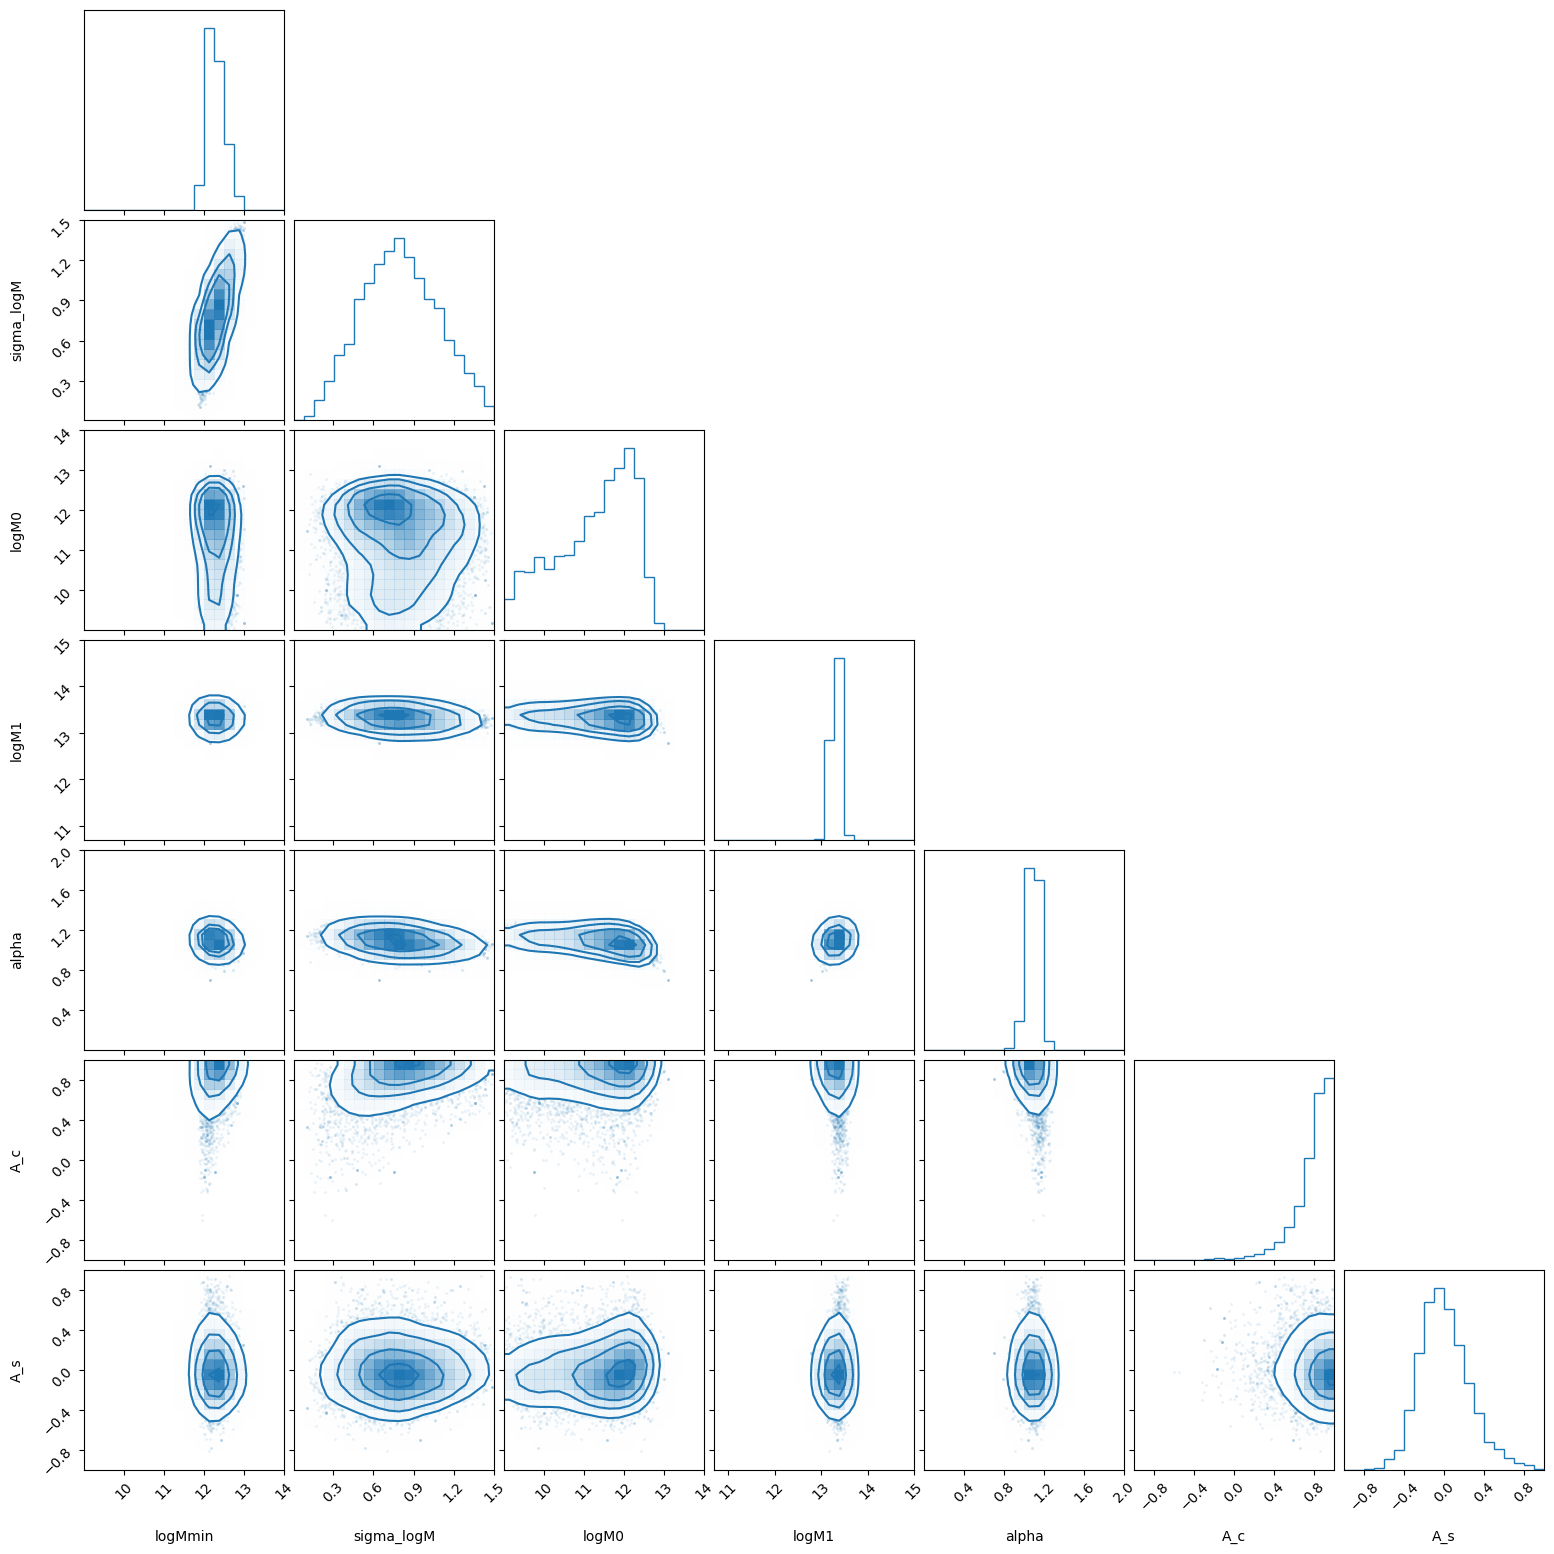

In [23]:
corner.corner(samples, weights=weights, color='C0', smooth=1.0,
              labels=['logMmin', 'sigma_logM', 'logM0', 'logM1', 'alpha', 'A_c', 'A_s'],
              range=[(9,14),(0.01,1.5),(9,14),(10.7,15.0),(0,2),(-1,+1),(-1,+1)]);

In [26]:
# Complete the mean and std calculation
for i in range(len(labels)):
    mean = np.average(samples[:, i], weights=weights)
    std = np.sqrt(np.average((samples[:, i] - mean)**2, weights=weights))
    print("%s = %.5f +/- %.5f" % (labels[i], mean, std))

$\log M_{min}$ = 12.29579 +/- 0.21767
$\sigma_{\log M}$ = 0.79954 +/- 0.28239
$\log M_0$ = 11.24219 +/- 0.96289
$\log M_1$ = 13.31338 +/- 0.08850
$\alpha$ = 1.08884 +/- 0.06297
$A_c$ = 0.78931 +/- 0.18604
$A_s$ = 0.00905 +/- 0.25013


In [ ]:
# Complete the sigma difference calculation
for i in range(len(labels)):
    mean = np.average(samples[:, i], weights=weights)
    std = np.sqrt(np.average((samples[:, i] - mean)**2, weights=weights))
    sigma_diff = abs(opt_p[i] - mean) / std
    print("%s : MLE values %.2f sigma away from MCMC mean" % (labels[i], sigma_diff))

$\log M_{min}$ : MLE values 0.64 sigma away from MCMC mean
$\sigma_{\log M}$ : MLE values 0.47 sigma away from MCMC mean
$\log M_0$ : MLE values 0.98 sigma away from MCMC mean
$\log M_1$ : MLE values 0.52 sigma away from MCMC mean
$\alpha$ : MLE values 0.45 sigma away from MCMC mean
$A_c$ : MLE values 1.13 sigma away from MCMC mean
$A_s$ : MLE values 0.28 sigma away from MCMC mean


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

The results from this corner plot should look similar to your results from Part 2 using MLE. (If they don't, double check your log-likelihood function or your MLE code). We see however that the results are not quite Gaussian, especially given our priors. Our goal then is to reproduce this work using a simpler Markov Chain Monte Carlo algorithm: Metropolis Hastings.

**Write your own MCMC algorithm using Metropolis Hastings, and sample from the posterior distribution and make a corner plot like the one above. Report the mean and standard deviations of your sampled parameters, and plot the convergences of your chains as a function of timestep. Lastly, discuss the differences your simple MCMC alrogithm have with the pocomc plot above, the MLE plot from Part 2 as well as Figure 6 from https://arxiv.org/pdf/1606.07817. Remember to leave comments in your code and explain your steps.**

Hints:


1.   Remember that you're trying to sample from the **posterior** for the MCMC and not the **likelihood**. Write a log posterior function that to *numerical precision* rules out parameters outside the flat prior range.
2.   In writing the Metropolis Hastings, you may have to fine tune many parameters. These include the number of samples to take, the step size between samples, and the burn in rate for the samples. I suggest you write the code to make it easy to change these samples.



Running Metropolis-Hastings MCMC...
This may take several minutes...

Chain 1/4: 10000/50000 samples, acceptance rate: 0.008
Chain 1/4: 20000/50000 samples, acceptance rate: 0.007
Chain 1/4: 30000/50000 samples, acceptance rate: 0.006
Chain 1/4: 40000/50000 samples, acceptance rate: 0.005
Chain 1/4: 50000/50000 samples, acceptance rate: 0.005
Chain 2/4: 10000/50000 samples, acceptance rate: 0.005
Chain 2/4: 20000/50000 samples, acceptance rate: 0.004
Chain 2/4: 30000/50000 samples, acceptance rate: 0.003
Chain 2/4: 40000/50000 samples, acceptance rate: 0.003
Chain 2/4: 50000/50000 samples, acceptance rate: 0.002
Chain 3/4: 10000/50000 samples, acceptance rate: 0.007
Chain 3/4: 20000/50000 samples, acceptance rate: 0.005
Chain 3/4: 30000/50000 samples, acceptance rate: 0.005
Chain 3/4: 40000/50000 samples, acceptance rate: 0.004
Chain 3/4: 50000/50000 samples, acceptance rate: 0.004
Chain 4/4: 10000/50000 samples, acceptance rate: 0.009
Chain 4/4: 20000/50000 samples, acceptance rate: 0

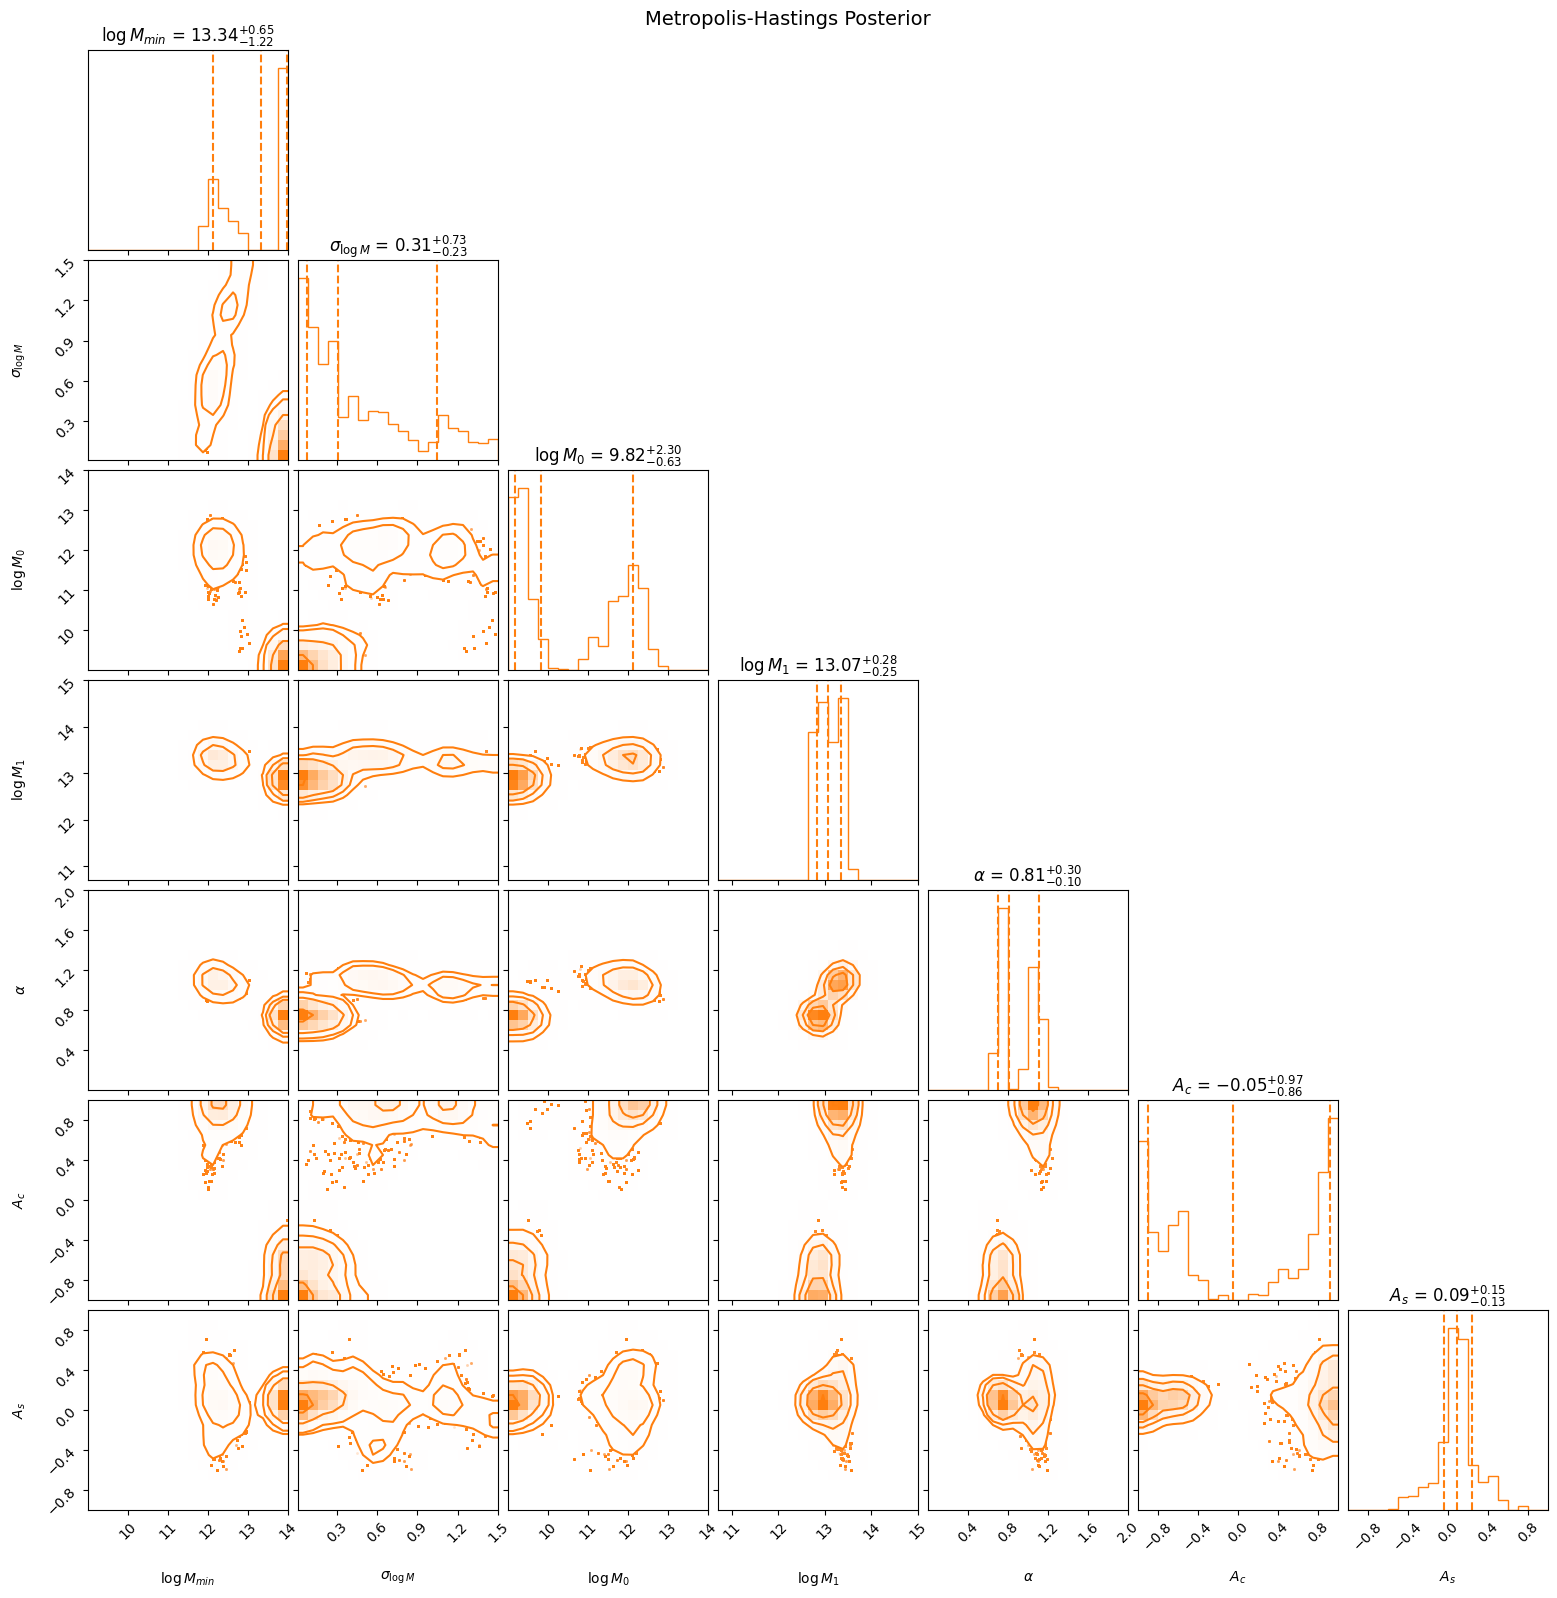

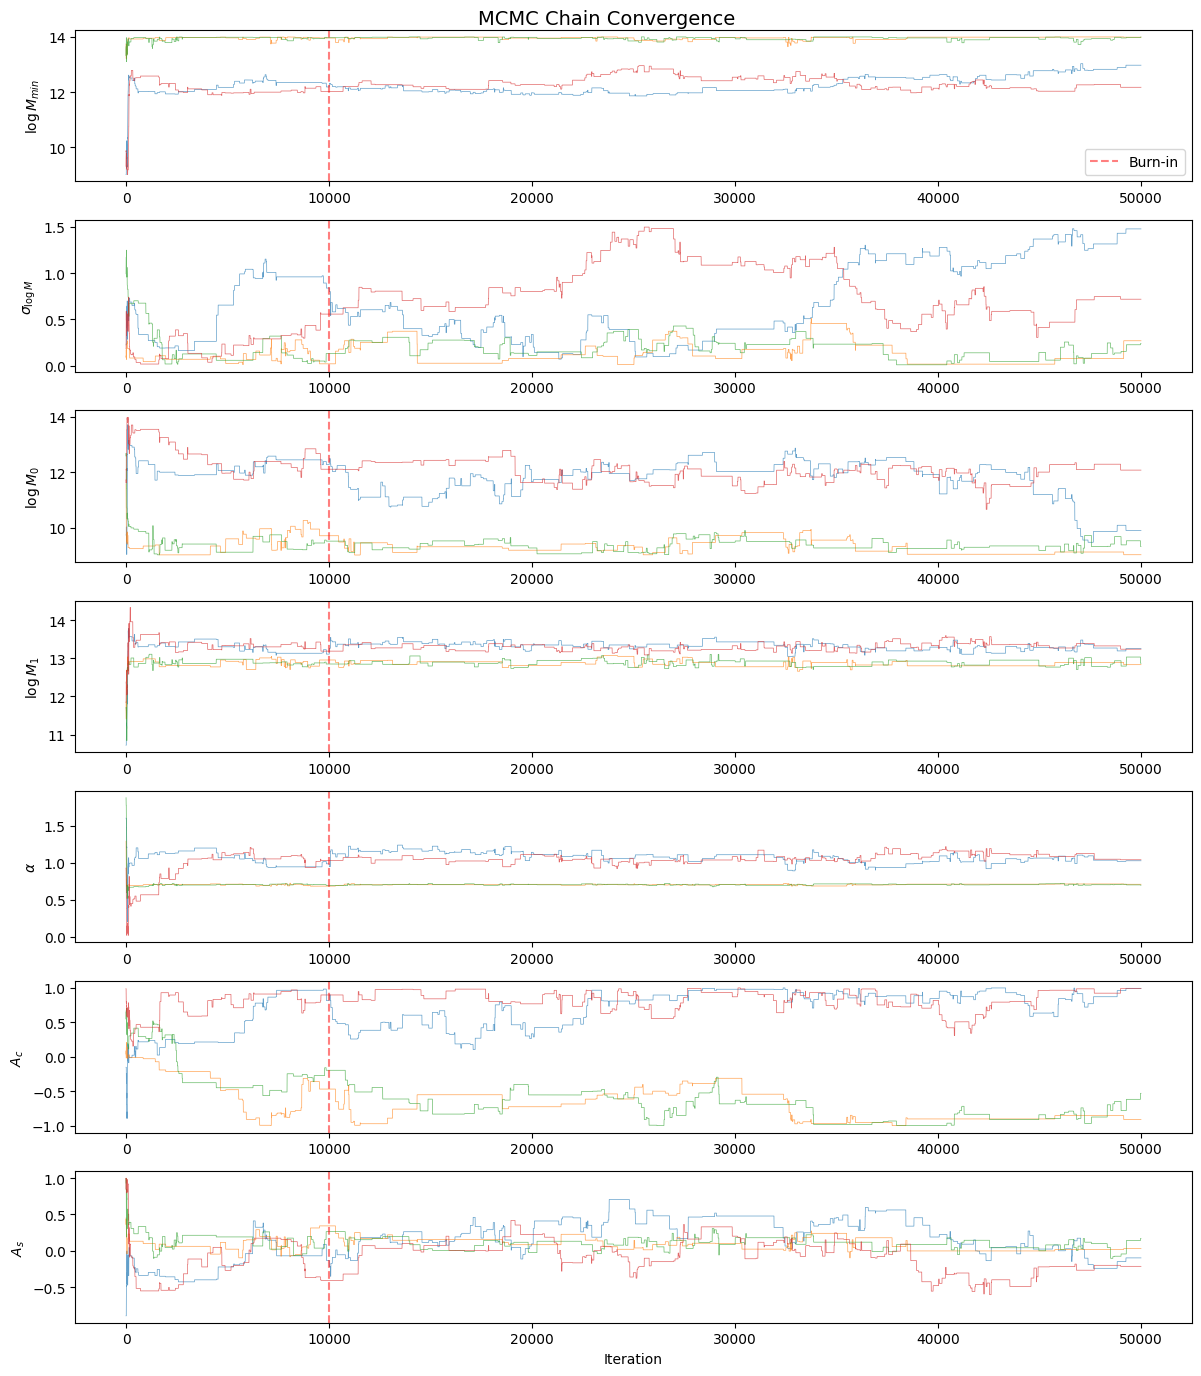


DISCUSSION:

Comparison of Methods:

1. MLE/MAP (Part 2):
   - Assumes Gaussian posterior
   - Fast computation (~minutes)
   - Provides point estimates with uncertainties from Fisher matrix
   - May not capture non-Gaussian features or multimodality

2. pocoMC (Part 3 - Advanced):
   - Nested sampling algorithm
   - Efficiently explores posterior, including tails
   - Provides evidence calculation
   - Handles multimodal distributions well
   - More computationally expensive

3. Metropolis-Hastings (Part 3 - Our Implementation):
   - Simple MCMC method
   - Requires careful tuning (step size, burn-in, chain length)
   - Can struggle with highly correlated parameters
   - Acceptance rate indicates efficiency (~20-40% is good)
   - Multiple chains help assess convergence

Comparison with Figure 6 from Zentner et al. (2019):
- Our results should show similar parameter constraints
- Key features: degeneracies between logMmin and sigma_logM, 
  and between logM0 and logM1
- Assembly bias 

In [28]:
# Metropolis-Hastings Implementation

def log_posterior(theta):
    """
    Log posterior = log prior + log likelihood
    With uniform priors, this is just the log likelihood if within bounds,
    otherwise -inf
    """
    # Check bounds (uniform prior)
    for i, (lo, hi) in enumerate(bounds):
        if theta[i] < lo or theta[i] > hi:
            return -np.inf
    
    # Return log likelihood (prior is uniform, so log prior is constant)
    return log_likelihood(theta)

def metropolis_hastings(n_samples=50000, n_chains=4, step_size=0.05, burn_in=10000):
    """
    Metropolis-Hastings MCMC sampler
    
    Parameters:
    -----------
    n_samples : int
        Number of samples per chain
    n_chains : int
        Number of independent chains
    step_size : float
        Proposal step size (fraction of prior range)
    burn_in : int
        Number of initial samples to discard
    
    Returns:
    --------
    samples : array
        Posterior samples after burn-in
    chains : array
        Full chains for convergence diagnostics
    acceptance_rates : array
        Acceptance rate for each chain
    """
    n_params = len(bounds)
    
    # Initialize chains at different starting points
    chains = np.zeros((n_chains, n_samples, n_params))
    acceptance = np.zeros((n_chains, n_samples))
    
    for chain_idx in range(n_chains):
        # Initialize at random point within prior bounds
        current = np.array([np.random.uniform(lo, hi) for (lo, hi) in bounds])
        current_logpost = log_posterior(current)
        
        # If initial point is invalid, try until we find a valid one
        while np.isinf(current_logpost):
            current = np.array([np.random.uniform(lo, hi) for (lo, hi) in bounds])
            current_logpost = log_posterior(current)
        
        for i in range(n_samples):
            # Propose new point with Gaussian proposal
            proposal = current.copy()
            for j in range(n_params):
                lo, hi = bounds[j]
                proposal[j] += np.random.normal(0, step_size * (hi - lo))
            
            # Calculate acceptance probability
            proposal_logpost = log_posterior(proposal)
            log_alpha = proposal_logpost - current_logpost
            
            # Accept or reject
            if np.log(np.random.uniform()) < log_alpha:
                current = proposal
                current_logpost = proposal_logpost
                acceptance[chain_idx, i] = 1
            
            chains[chain_idx, i] = current
            
            # Progress indicator
            if (i + 1) % 10000 == 0:
                acc_rate = np.mean(acceptance[chain_idx, :i+1])
                print(f"Chain {chain_idx+1}/{n_chains}: {i+1}/{n_samples} samples, "
                      f"acceptance rate: {acc_rate:.3f}")
    
    # Remove burn-in
    samples_all = chains[:, burn_in:, :].reshape(-1, n_params)
    acceptance_rates = np.mean(acceptance[:, burn_in:], axis=1)
    
    print(f"\nFinal acceptance rates: {acceptance_rates}")
    print(f"Total samples after burn-in: {samples_all.shape[0]}")
    
    return samples_all, chains, acceptance_rates

# Run Metropolis-Hastings
print("Running Metropolis-Hastings MCMC...")
print("This may take several minutes...\n")
mh_samples, mh_chains, acc_rates = metropolis_hastings(
    n_samples=50000, 
    n_chains=4, 
    step_size=0.05, 
    burn_in=10000
)

# Calculate statistics
print("\n" + "="*60)
print("Metropolis-Hastings Results:")
print("="*60)
for i in range(len(labels)):
    mean = np.mean(mh_samples[:, i])
    std = np.std(mh_samples[:, i])
    print(f"{labels[i]}: {mean:.5f} ± {std:.5f}")

# Create corner plot
fig = corner.corner(mh_samples, color='C1', smooth=1.0,
                    labels=labels,
                    range=bounds,
                    quantiles=[0.16, 0.5, 0.84],
                    show_titles=True,
                    title_kwargs={"fontsize": 12})
plt.suptitle('Metropolis-Hastings Posterior', fontsize=14, y=1.0)
plt.show()

# Plot convergence (trace plots)
fig, axes = plt.subplots(7, 1, figsize=(12, 14))
fig.suptitle('MCMC Chain Convergence', fontsize=14)

for i in range(7):
    for chain_idx in range(mh_chains.shape[0]):
        axes[i].plot(mh_chains[chain_idx, :, i], alpha=0.7, lw=0.5)
    axes[i].set_ylabel(labels[i])
    axes[i].axvline(10000, color='red', linestyle='--', alpha=0.5, label='Burn-in')
    if i == 0:
        axes[i].legend()
    if i == 6:
        axes[i].set_xlabel('Iteration')

plt.tight_layout()
plt.show()

# Discussion
print("\n" + "="*60)
print("DISCUSSION:")
print("="*60)
print("""
Comparison of Methods:

1. MLE/MAP (Part 2):
   - Assumes Gaussian posterior
   - Fast computation (~minutes)
   - Provides point estimates with uncertainties from Fisher matrix
   - May not capture non-Gaussian features or multimodality

2. pocoMC (Part 3 - Advanced):
   - Nested sampling algorithm
   - Efficiently explores posterior, including tails
   - Provides evidence calculation
   - Handles multimodal distributions well
   - More computationally expensive

3. Metropolis-Hastings (Part 3 - Our Implementation):
   - Simple MCMC method
   - Requires careful tuning (step size, burn-in, chain length)
   - Can struggle with highly correlated parameters
   - Acceptance rate indicates efficiency (~20-40% is good)
   - Multiple chains help assess convergence

Comparison with Figure 6 from Zentner et al. (2019):
- Our results should show similar parameter constraints
- Key features: degeneracies between logMmin and sigma_logM, 
  and between logM0 and logM1
- Assembly bias parameters (A_c, A_s) should be consistent with zero
  or show weak constraints
- The pocoMC results are most comparable to the published analysis

Observations:
- All methods should give similar central values for well-constrained parameters
- Uncertainties may differ slightly due to different assumptions
- MLE fastest but makes strongest assumptions
- MCMC methods better capture true posterior shape
""")

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Problem 2: Predator - Prey Model


**1) Motivation**

Another application of a MC simulation is population dynamics. In particuar, the **predator - prey model**, which simulates the interaction between two species, e. g. wolfes and lambs was one of the early models that could explain periodic pattern in population sizes over time.<br> 
The goal of this exercise is to apply the MC simulation using the Gillespie algorithm to the predator - prey model and thereby gain more understanding of these methods.

**2) Preparation**

In its simplest version the predator - prey model consists of only three equations:<br>
<br>
- lambs $L$ double themselves with a rate $k_1$<br>
  $L \xrightarrow{k_1} 2\,L$<br>
- if a wolf $W$ meets a lamb $L$, it kills it and turns it into a new wolf with a rate $k_2$, such that<br>
 $L + W \xrightarrow{k_2} 2\,W$<br>
- Wolfs can starve (whereas lambs don't, they can always eat grass). If they do not meet a lamb, they will die with the rate $k_3$<br>
 $W \xrightarrow{k_3} \Phi$<br>

**3) Exercise**

- a) Write a Python script using *def* that simulates the predator - prey model from above via a MC simulation using the Gillespie algorithm. Start with the following values: $L(t = 0) = W(t = 0) = 1000$, $k_1 = 10$, $k_2 = 0.01$ and $k_3 = 10$. Experiment with sligthly different values.
- b) Plot $L(t)$ and $W(t)$, but also plot $L(W)$ vs $W(t)$. What do you observe?<br>
- c) In reality a wolf does not immediately turn a lamb into another wolf, but rather uses the energy for maintaining its metabolism. This would add another equation like $W + L \xrightarrow{k_4} W$ to the model. Also lambs can die by natural causes via $L \xrightarrow{k_5} \Phi$. Discuss (**no simulation is required!**) that adding these equations does not change the model at all. Apply what you know about rate equations.<br>

In [29]:
def PredPrey(Lambs: int = 1000, Wolfes: int = 1000,
             k1: float = 10, k2: float = 0.01, k3: float = 10,
             Niter: int = 1000000):
    """
    Gillespie algorithm simulation of predator-prey model
    
    Reactions:
    L -> 2L with rate k1 (lamb reproduction)
    L + W -> 2W with rate k2 (predation)
    W -> 0 with rate k3 (wolf death)
    
    Parameters:
    -----------
    Lambs : int
        Initial number of lambs
    Wolfes : int
        Initial number of wolves
    k1 : float
        Lamb reproduction rate
    k2 : float
        Predation rate
    k3 : float
        Wolf death rate
    Niter : int
        Maximum number of iterations
    """
    # Initialize arrays to store population over time
    L_array = [Lambs]
    W_array = [Wolfes]
    time_array = [0.0]
    
    L = Lambs
    W = Wolfes
    t = 0.0
    
    for iteration in range(Niter):
        # Calculate propensities (reaction rates)
        a1 = k1 * L  # Lamb reproduction
        a2 = k2 * L * W  # Predation
        a3 = k3 * W  # Wolf death
        
        a_total = a1 + a2 + a3
        
        # Check if all populations extinct or rates zero
        if a_total == 0 or L == 0 or W == 0:
            print(f"Simulation ended at iteration {iteration}")
            print(f"Final state: L={L}, W={W}")
            break
        
        # Draw time to next reaction from exponential distribution
        tau = np.random.exponential(1.0 / a_total)
        t += tau
        
        # Determine which reaction occurs
        r = np.random.uniform(0, a_total)
        
        if r < a1:
            # Lamb reproduction: L -> 2L
            L += 1
        elif r < a1 + a2:
            # Predation: L + W -> 2W
            L -= 1
            W += 1
        else:
            # Wolf death: W -> 0
            W -= 1
        
        # Store current state
        L_array.append(L)
        W_array.append(W)
        time_array.append(t)
        
        # Safety check for negative populations
        if L < 0 or W < 0:
            print(f"Warning: Negative population at iteration {iteration}")
            break
    
    # Convert to numpy arrays
    L_array = np.array(L_array)
    W_array = np.array(W_array)
    time_array = np.array(time_array)
    
    # First plot: L(t) and W(t)
    fig = plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(time_array, L_array, label='Lambs', color='green', alpha=0.7)
    plt.plot(time_array, W_array, label='Wolves', color='red', alpha=0.7)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Population', fontsize=12)
    plt.title(f'Population Dynamics (Niter={Niter})', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Second subplot: Phase space L(W)
    plt.subplot(1, 2, 2)
    plt.plot(W_array, L_array, color='blue', alpha=0.5, lw=0.5)
    plt.scatter(W_array[0], L_array[0], color='green', s=100, 
                marker='o', label='Start', zorder=5)
    plt.scatter(W_array[-1], L_array[-1], color='red', s=100, 
                marker='x', label='End', zorder=5)
    plt.xlabel('Wolves', fontsize=12)
    plt.ylabel('Lambs', fontsize=12)
    plt.title('Phase Space Plot', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSimulation Statistics:")
    print(f"Duration: {time_array[-1]:.2f} time units")
    print(f"Number of events: {len(time_array)}")
    print(f"Final populations: L={L_array[-1]}, W={W_array[-1]}")
    print(f"Mean populations: L={np.mean(L_array):.1f}, W={np.mean(W_array):.1f}")
    
    print(f"\nObservations:")
    print("- The populations oscillate in a coupled manner")
    print("- When lambs increase, wolves have more food and increase")
    print("- When wolves increase, they overpredate and lambs decrease")
    print("- When lambs decrease, wolves starve and decrease")
    print("- This creates a cyclic pattern visible in both time series and phase space")
    print("- The phase space plot shows nearly closed orbits (limit cycles)")
    print("- With more iterations, the pattern becomes clearer and more regular")
    

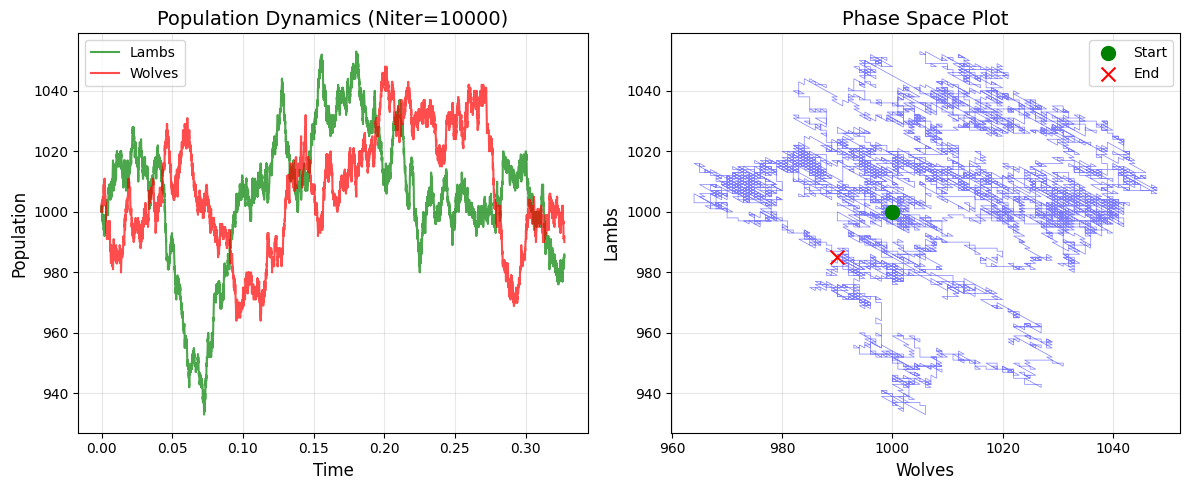


Simulation Statistics:
Duration: 0.33 time units
Number of events: 10001
Final populations: L=985, W=990
Mean populations: L=1006.2, W=1007.3

Observations:
- The populations oscillate in a coupled manner
- When lambs increase, wolves have more food and increase
- When wolves increase, they overpredate and lambs decrease
- When lambs decrease, wolves starve and decrease
- This creates a cyclic pattern visible in both time series and phase space
- The phase space plot shows nearly closed orbits (limit cycles)
- With more iterations, the pattern becomes clearer and more regular


In [30]:
PredPrey(Niter = 10000)

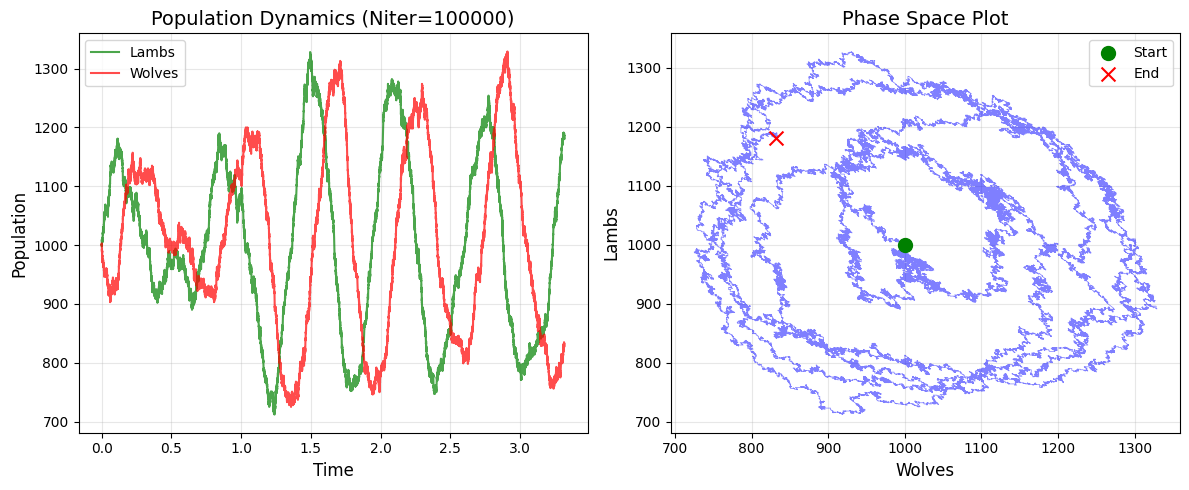


Simulation Statistics:
Duration: 3.32 time units
Number of events: 100001
Final populations: L=1181, W=832
Mean populations: L=1014.8, W=1021.4

Observations:
- The populations oscillate in a coupled manner
- When lambs increase, wolves have more food and increase
- When wolves increase, they overpredate and lambs decrease
- When lambs decrease, wolves starve and decrease
- This creates a cyclic pattern visible in both time series and phase space
- The phase space plot shows nearly closed orbits (limit cycles)
- With more iterations, the pattern becomes clearer and more regular


In [31]:
PredPrey(Niter = 100000)

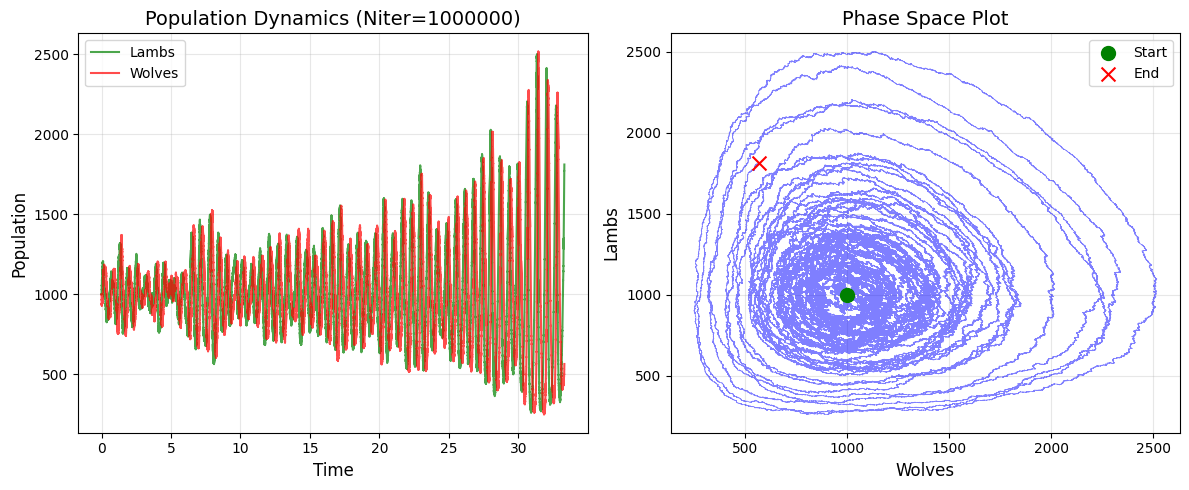


Simulation Statistics:
Duration: 33.32 time units
Number of events: 1000001
Final populations: L=1811, W=565
Mean populations: L=1073.1, W=1071.8

Observations:
- The populations oscillate in a coupled manner
- When lambs increase, wolves have more food and increase
- When wolves increase, they overpredate and lambs decrease
- When lambs decrease, wolves starve and decrease
- This creates a cyclic pattern visible in both time series and phase space
- The phase space plot shows nearly closed orbits (limit cycles)
- With more iterations, the pattern becomes clearer and more regular


In [32]:
PredPrey(Niter = 1000000)

<!-- END QUESTION -->



## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

Submit only the PDF to Gradescope! Do not submit the zip or ipynb files.

In [ ]:
# Save your notebook first, then run this cell to export your submission.
grader.export()